--- OPTION PRICING RESULTS ---
Asset: Stock S=$100, Strike K=$105
1. Black-Scholes Price: $8.0214 (The 'Truth')
2. Monte Carlo Price:   $8.0152 (The Simulation)
Difference:             $0.0061


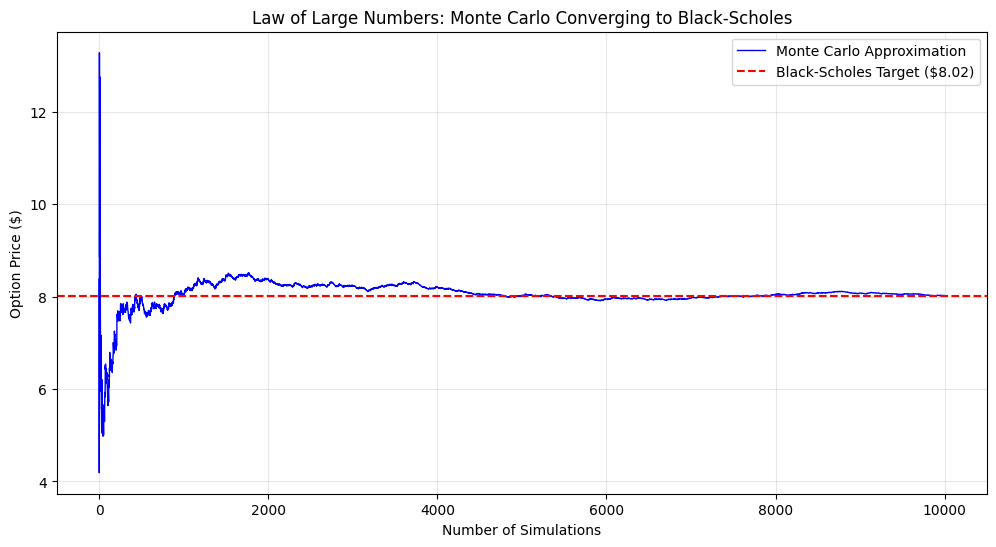

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==========================================
# 1. SETTINGS (The "Greeks" inputs)
# ==========================================
S = 100      # Current Stock Price
K = 105      # Strike Price (Target)
T = 1        # Time to Maturity (1 Year)
r = 0.05     # Risk-Free Rate (5%)
sigma = 0.2  # Volatility (20%)

# ==========================================
# 2. METHOD A: BLACK-SCHOLES (The Exact Math)
# ==========================================
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = (S * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2))
    return call_price

bs_price = black_scholes_call(S, K, T, r, sigma)

# ==========================================
# 3. METHOD B: MONTE CARLO (The Simulation)
# Logic: Simulate geometric Brownian motion (GBM)
# ==========================================
np.random.seed(42)
N = 50000  # Number of Simulations

# Generate N random Z-scores (Standard Normal Distribution)
Z = np.random.standard_normal(N)

# Calculate Stock Price at Maturity (S_T) using Geometric Brownian Motion formula
# Formula: S_T = S * exp((r - 0.5*sigma^2)T + sigma*sqrt(T)*Z)
ST = S * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)

# Calculate Payoff for Call Option: max(S_T - K, 0)
payoffs = np.maximum(ST - K, 0)

# Discount average payoff back to present value
mc_price = np.exp(-r * T) * np.mean(payoffs)

# ==========================================
# 4. VISUALIZATION (Convergence)
# Show how the price stabilizes as N increases
# ==========================================
# Calculate running average of the first 10,000 sims to show convergence
running_sum = np.cumsum(payoffs[:10000])
running_avg = (running_sum / np.arange(1, 10001)) * np.exp(-r * T)

print(f"--- OPTION PRICING RESULTS ---")
print(f"Asset: Stock S=${S}, Strike K=${K}")
print(f"1. Black-Scholes Price: ${bs_price:.4f} (The 'Truth')")
print(f"2. Monte Carlo Price:   ${mc_price:.4f} (The Simulation)")
print(f"Difference:             ${abs(bs_price - mc_price):.4f}")

plt.figure(figsize=(12, 6))
plt.plot(running_avg, color='blue', label='Monte Carlo Approximation', linewidth=1)
plt.axhline(y=bs_price, color='red', linestyle='--', label=f'Black-Scholes Target (${bs_price:.2f})')
plt.title("Law of Large Numbers: Monte Carlo Converging to Black-Scholes")
plt.xlabel("Number of Simulations")
plt.ylabel("Option Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()